In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

In [ ]:
# Make reproducible
# Fixing seeds means every run produces the same weight initialisations and same train/val split
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
# Check environment
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.21.0
Keras version      : 3.13.2
GPU available      : False


In [ ]:
# Load data
os.getcwd()

'c:\\dev\\digit-cnn'

In [ ]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

In [15]:
print(f"Train info: \n{train_df.info()}\n")
print(f"Test info: \n{test_df.info()}")

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB
Train info: 
None

<class 'pandas.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB
Test info: 
None


In [17]:
train_df.head(20)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Separate labels and pixels
y_train_raw = train_df["label"].values        # shape: (42000,)
X_train_raw = train_df.drop("label", axis=1).values  # shape: (42000, 784)
X_test_raw  = test_df.values                  # shape: (28000, 784)

print(f"Label values: \n{y_train_raw}")
print(f"Shape: {y_train_raw.shape}\n")

print(f"Train pixels shape: \n{X_train_raw}")
print(f"Shape: {X_train_raw.shape}\n")


Label values: 
[1 0 1 ... 7 6 9]
Shape: (42000,)

Train pixels shape: 
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Shape: (42000, 784)



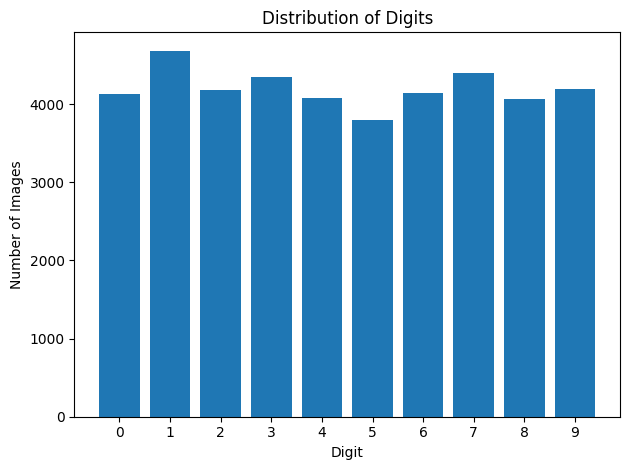

Distribution of digits in dataset: 
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


In [96]:

counts = pd.Series(y_train_raw).value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Distribution of Digits")
plt.tight_layout()
plt.show()

print(f"Distribution of digits in dataset: \n{counts}")


In [48]:
# Normalise pixel values to [0, 1] 
# Raw values are 0–255. Large input values cause large activations which
# destabilise gradient updates. 
X_train_norm = X_train_raw / 255.0
X_test_norm  = X_test_raw  / 255.0

print(f"Pixel range before: {X_train_raw.min()} - {X_train_raw.max()}")
print(f"Pixel range after:  {X_train_norm.min():.1f} - {X_train_norm.max():.1f}")

Pixel range before: 0 - 255
Pixel range after:  0.0 - 1.0


In [ ]:
# Reshape from flat vectors to 2D images
# Take dense layers to Conv2D layers expect (samples, height, width, channels).
# MNIST is greyscale so channels is 1, unlike coloured images which is 3 (RGB).
# This restores the spatial structure that was lost
X_train = X_train_norm.reshape((-1, 28, 28, 1))
X_test  = X_test_norm.reshape((-1, 28, 28, 1))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")   

X_train shape: (42000, 28, 28, 1)
X_test shape:  (28000, 28, 28, 1)


In [88]:
# Look at pixels 16-20 of rows 16-20 of images 355, 356, and 357 
# just to gauge array structure
X_train[355:358, 16:20, 16:20].squeeze()

array([[[0.74509804, 0.        , 0.        , 0.        ],
        [0.10980392, 0.        , 0.        , 0.        ],
        [0.04313725, 0.        , 0.        , 0.        ],
        [0.64313725, 0.        , 0.        , 0.        ]],

       [[0.95294118, 0.99215686, 0.3254902 , 0.        ],
        [0.99215686, 0.90196078, 0.10588235, 0.        ],
        [0.99215686, 0.38431373, 0.        , 0.        ],
        [0.7372549 , 0.00784314, 0.        , 0.        ]],

       [[0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.61960784],
        [0.17647059, 0.54117647, 0.91372549, 0.99215686]]])

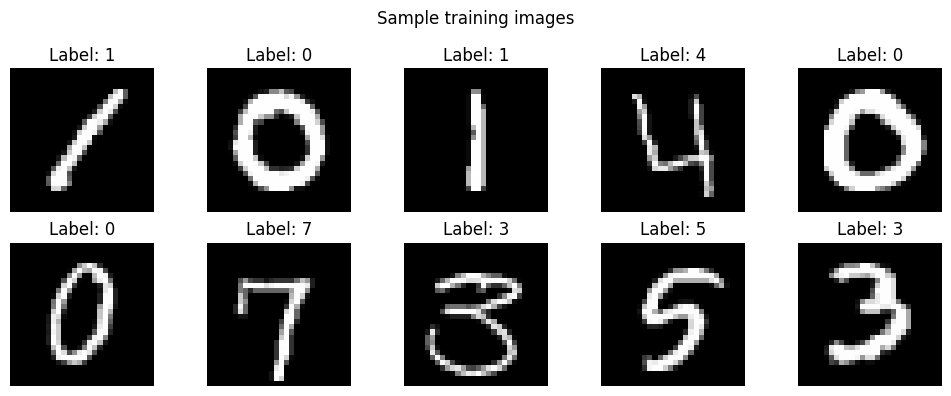

In [ ]:
# Plot sample images, showing they match labels
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap="grey")
    ax.set_title(f"Label: {y_train_raw[i]}")
    ax.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

In [93]:
# Train / validation split
# Hold out 10% for validation and stratify
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_raw,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train_raw
)

In [94]:

print(f"Training samples:   {len(X_tr)}")
print(f"Validation samples: {len(X_val)}") 

Training samples:   37800
Validation samples: 4200


In [98]:
# Build model 
# Layers execute sequentially. Namely, one after another, output of each feeds the next.
def build_model():
    model = keras.Sequential([

        # Block 1
        layers.Conv2D(32, (3, 3), padding="same", input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_model()
model.summary()

c:\dev\digit-cnn\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)